In [52]:
import pandas as pd

# 1. Загружаем объединенный файл (или используем final_df, если запускаете в том же скрипте)
# Убедитесь, что этот шаг идет ПОСЛЕ того, как вы применили поправку на влажность!
final_df = pd.read_csv('all_points_combined.csv') 

# --- Здесь в вашем коде уже отработал блок коррекции PM1.0, PM2.5, PM10 ---

# 2. Фильтруем строки: оставляем только те, где в имени файла содержится 'park'
# (параметр case=False застрахует от различий в регистре, например Park vs park)
parks_only_df = final_df[final_df['source_file'].str.contains('park', case=False, na=False)]

# 3. Сохраняем результат в отдельный файл
parks_only_df.to_csv('all_park_combined.csv', index=False)

In [24]:
df1 = pd.read_csv('all_dvor_combined.csv')
df2 = pd.read_csv('all_magistral_combined.csv')
df3 = pd.read_csv('all_parks_combined.csv')

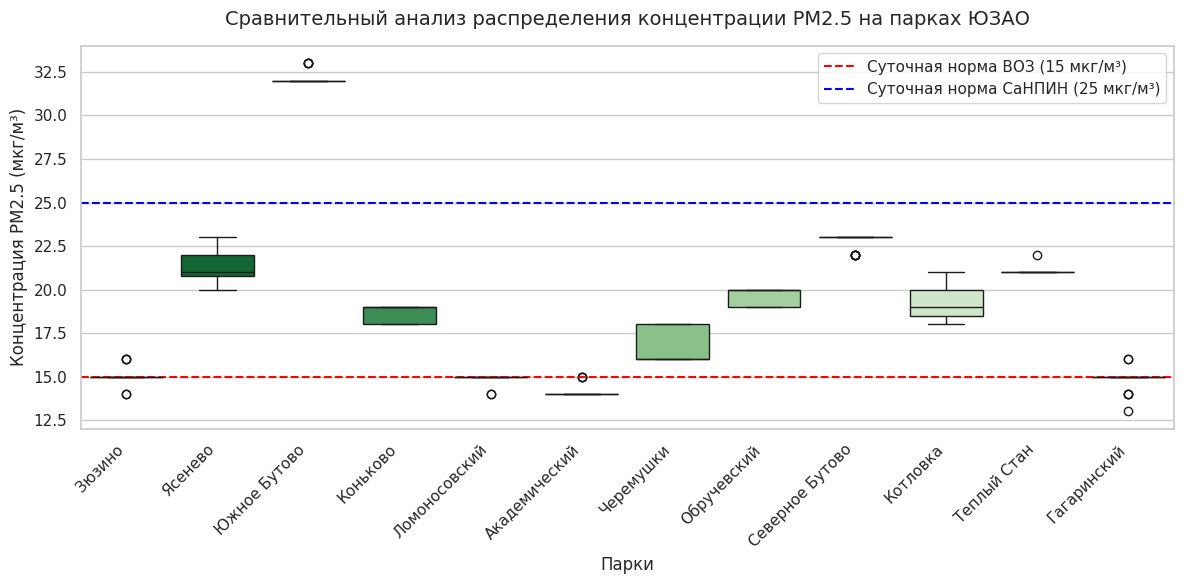

In [53]:


import seaborn as sns
import matplotlib.pyplot as plt

beautify_labels = {
    'Zuzino_park.CSV': 'Зюзино',
    'Obruchevskiy_park.CSV': 'Обручевский',
    'Lomonosovskiy_park.CSV': 'Ломоносовский',
    'Konkovo_park.CSV': 'Коньково',
    'Akademicheskaya_park.CSV': 'Академический',
    'Gagarinskiy_park.CSV': 'Гагаринский',
    'NButovo_park.CSV': 'Северное Бутово',
    'SButovo_park.CSV': 'Южное Бутово',
    'Yasenevo_park.CSV': 'Ясенево',
    'Cheremushki_park.CSV': 'Черемушки',
    'Tepliy_park.CSV': 'Теплый Стан',
    'Kotlovka_park.CSV': 'Котловка'
}
plot_df = parks_only_df.copy()
plot_df['district_clean'] = plot_df['source_file'].map(beautify_labels)
# Настраиваем стиль графика
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Строим Boxplot
ax = sns.boxplot(
    data=plot_df, 
    x='district_clean', 
    y='PM2.5', 
    hue='district_clean',
    palette='Greens_r',
    legend=False
)

# Красиво разворачиваем подписи парков, чтобы они не налезали друг на друга
plt.xticks(rotation=45, ha='right')

# Добавляем строгие академические подписи
plt.title('Сравнительный анализ распределения концентрации PM2.5 на парках ЮЗАО', fontsize=14, pad=15)
plt.xlabel('Парки', fontsize=12)
plt.ylabel('Концентрация PM2.5 (мкг/м³)', fontsize=12)

# Жесткая суточная норма ВОЗ для наглядности
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Суточная норма ВОЗ (15 мкг/м³)')
plt.legend()

plt.axhline(y=25, color='blue', linestyle='--', linewidth=1.5, label='Суточная норма СаНПИН (25 мкг/м³)')
plt.legend()

plt.tight_layout()
plt.savefig('park_pm25_comparison.png', dpi=300) # Сохраняем в высоком качестве для презентации
plt.show()